# Effective Propositionalisation

Forming an effective propositionalisation of a real-valued dataset is a complex task.

Basic desidarata:

1. consistent, i.e., discretized variable converges to undiscretized variable for $n \to \infty$
2. efficient, i.e., rate of convergence as fast as possible
3. parsimonious, i.e., number of bins / thresholds as small as possible

Additional semantic desiderata:

4. interpretability, bins / thresholds can be named easily
5. mass faithful, values with discrete probability mass obtain dedicated threshold for small $n$, in particular, variables that are already discrete are faithfully reconstructed for small $n$
6. mode faithful, for multi-modal distributions, the discretized variable is able to separate all modes for small $n$

In addition, simplicty is always desired. Hence, we are willing to sacrifice indivudal critera to have, in first instance, a robust and transparent way to approximately satisfy the other criteria via readily available numpy functions. In particular, the investigated candidates are

- quantile-based (equal frequency) discretisation as provided by `numpy.quantiles` with a logarithmic number of thresholds,
- equal width binning methods for density approximation implemented in `numpy.histogram_bin_edges`.

Immediate concern about those approaches that come to mind are:

- Quantile-based discretisation provides uniform binnings, hence, it does not generally allow to separate outliers. This might in the end be related to the mode faithfulness, but there might be other more subtle issues that are unclear without a deeper study of the literature. The histogram methods have a more authorotative feel to them overall when it comes to continuous, mainly by their reference to the literature.

- Equal-width binning, on the other hand, is less transparent and interpretable. In particular, it is not easy to name the resulting thresholds other than through the thresholds themselves (in contrast to percentile-based thresholds). 

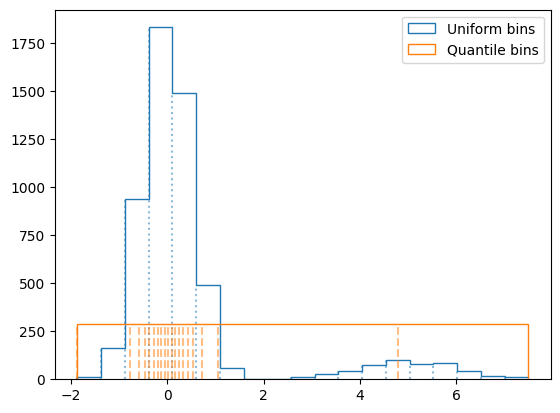

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data
np.random.seed(0)
x = np.concatenate([np.random.normal(0, 0.5, 5000), np.random.normal(5, 1, 500)])

# Bin edges
bins_uniform = np.linspace(np.min(x), np.max(x), 20)
bins_quantile = np.quantile(x, np.linspace(0, 1, 20))

# Plot
fig, ax = plt.subplots()

# Uniform histogram
counts_uniform, edges_uniform, _ = ax.hist(x, bins=bins_uniform, histtype='step', label='Uniform bins', color='C0')
for i in range(len(edges_uniform)-1):
    ax.vlines(edges_uniform[i], 0, counts_uniform[i], color='C0', linestyle=':', alpha=0.5)

# Quantile histogram
counts_quantile, edges_quantile, _ = ax.hist(x, bins=bins_quantile, histtype='step', label='Quantile bins', color='C1')
for i in range(len(edges_quantile)-1):
    ax.vlines(edges_quantile[i], 0, counts_quantile[i], color='C1', linestyle='--', alpha=0.5)

ax.legend()
plt.show()

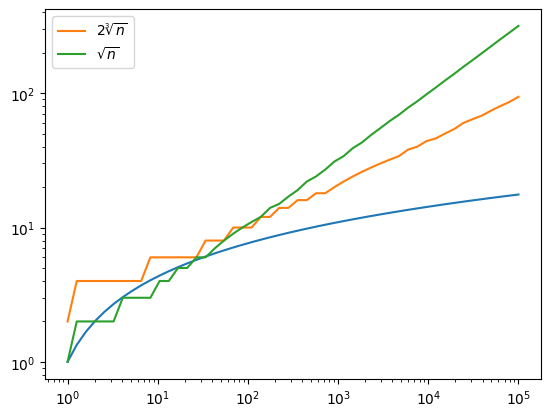

In [7]:
ns = np.geomspace(1, 100000)
plt.plot(ns, np.log2(ns)+1)
# plt.plot(ns, np.maximum(1, 2*np.ceil(ns**(1/3)).astype(int)))
plt.plot(ns, 2*np.ceil(ns**(1/3)), label=r'$2\sqrt[3]{n}$')
plt.plot(ns, np.ceil(ns**(1/2)), label=r'$\sqrt{n}$')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

In [3]:
import numpy as np
from numba.types import int32, float64
from numba.experimental import jitclass

@jitclass
class LeanPropositionalization:

    v: int32[:]
    t: float64[:]
    s: int32[:]

    def __init__(self, v, t, s):
        self.v = v
        self.t = t
        self.s = s

    def support(self, p, x):
        return np.flatnonzero(self.s[p]*x[:,self.v[p]] >= self.t[p])
    
    def binarize(self, x):
        return self.s*x[:, self.v] >= self.t
    
    def __len__(self):
        return len(self.v)

def quantile_based_propositionalization(x, k=None):
    n, d = x.shape
    k = k if k is not None else 2*np.ceil(n**(1/3)).astype(int)
    quantile_targets = np.linspace(0, 1, k + 1)[1:-1]

    quantiles = np.quantile(x, quantile_targets, axis=0)  # shape (n_splitpoints, n_cols)
    v = np.repeat(np.arange(d), quantiles.shape[0]).astype(np.int32)
    t = quantiles.flatten()

    # eliminate duplicate thresholds
    keep = np.empty_like(v, dtype=bool)
    keep[0] = True
    keep[1:] = (v[1:] != v[:-1]) | (t[1:] != t[:-1])
    v, t = v[keep], t[keep]

    s = np.repeat([1, -1], len(v)).astype(np.int32)
    return LeanPropositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

In [4]:
from numba.types import int64

@jitclass
class FatPropositionalization:

    v: int64[:]
    t: float64[:]
    s: int64[:]

    def __init__(self, v, t, s):
        self.v = v
        self.t = t
        self.s = s

    def support(self, p, x):
        return np.flatnonzero(self.s[p]*x[:,self.v[p]] >= self.t[p])
    
    def binarize(self, x):
        return self.s*x[:, self.v] >= self.t
    
    def __len__(self):
        return len(self.v)

def quantile_based_fat_propositionalization(x, k=None):
    n, d = x.shape
    k = k if k is not None else 2*np.ceil(n**(1/3)).astype(int)
    quantile_targets = np.linspace(0, 1, k + 1)[1:-1]

    quantiles = np.quantile(x, quantile_targets, axis=0)  # shape (n_splitpoints, n_cols)
    v = np.repeat(np.arange(d), quantiles.shape[0])
    t = quantiles.flatten()

    # eliminate duplicate thresholds
    keep = np.empty_like(v, dtype=bool)
    keep[0] = True
    keep[1:] = (v[1:] != v[:-1]) | (t[1:] != t[:-1])
    v, t = v[keep], t[keep]

    s = np.repeat([1, -1], len(v))
    return FatPropositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

In [5]:
def equal_width_propositionalization_numpy(x):
    n, d = x.shape

    x_sorted = np.sort(x, axis=0)
    q25 = x_sorted[int(0.25 * (n-1)), :]
    q75 = x_sorted[int(0.75 * (n-1)), :]
    iqr = q75 - q25

    width = 2 * iqr / np.maximum(1, n**(1/3))
    l = x_sorted[0, :]
    u = x_sorted[-1, :]

    v = []
    t = []

    for j in range(d):
        if width[j] == 0 or u[j] == l[j]:
            continue

        n_bins = int(np.ceil((u[j] - l[j]) / width[j]))
        if n_bins <= 1:
            continue

        edges = l[j] + width[j] * np.arange(1, n_bins)

        col_data = x_sorted[:, j]
        positions = np.searchsorted(col_data, edges, side='left')
        positions_ext = np.empty(len(positions) + 1, dtype=np.int64)
        positions_ext[0] = 0
        positions_ext[1:] = positions
        diffs = np.diff(positions_ext)
        nontrivial = diffs > 0

        edges = edges[nontrivial]
        v.extend([j] * len(edges))
        t.extend(edges)

    v = np.array(v, dtype=np.int64)
    t = np.array(t, dtype=np.float64)
    s = np.repeat([1, -1], len(v))
    return FatPropositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)


In [6]:
import numpy as np
from numba import njit

def equal_width_propositionalization(x):
    return equal_width_propositionalization_sorted(np.sort(x, axis=0))

@njit
def equal_width_propositionalization_sorted(x_sorted):
    n, d = x_sorted.shape

    max_possible = d * n
    v = np.empty(max_possible, dtype=np.int32)
    t = np.empty(max_possible, dtype=np.float64)
    idx = 0

    for j in range(d):
        col_data = x_sorted[:, j]
        l_j = col_data[0]
        u_j = col_data[-1]

        if u_j == l_j:
            continue

        q25 = col_data[int(0.25 * (n-1))]
        q75 = col_data[int(0.75 * (n-1))]
        iqr = q75 - q25

        width = 2 * iqr / max(1, n**(1/3))
        if width == 0:
            continue

        n_bins = int(np.ceil((u_j - l_j) / width))
        if n_bins <= 1:
            continue

        edges = l_j + width * np.arange(1, n_bins)

        positions = np.searchsorted(col_data, edges, side='left')
        positions_ext = np.empty(len(positions) + 1, dtype=np.int32)
        positions_ext[0] = 0
        positions_ext[1:] = positions
        diffs = np.diff(positions_ext)
        nontrivial = diffs > 0

        for k in range(len(edges)):
            if nontrivial[k]:
                v[idx] = j
                t[idx] = edges[k]
                idx += 1

    v = v[:idx]
    t = t[:idx]
    s = np.repeat(np.array([1, -1], dtype=np.int32), len(v)).astype(np.int32)
    return LeanPropositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)


# @njit
# def equal_width_propositionalization(x):
#     n, d = x.shape

#     max_possible = d * n
#     v = np.empty(max_possible, dtype=np.int64)
#     t = np.empty(max_possible, dtype=np.float64)
#     idx = 0

#     for j in range(d):
#         col_data = np.sort(x[:, j])
#         l_j = col_data[0]
#         u_j = col_data[-1]

#         if u_j == l_j:
#             continue

#         q25 = col_data[int(0.25 * (n-1))]
#         q75 = col_data[int(0.75 * (n-1))]
#         iqr = q75 - q25

#         width = 2 * iqr / max(1, n**(1/3))
#         if width == 0:
#             continue

#         n_bins = int(np.ceil((u_j - l_j) / width))
#         if n_bins <= 1:
#             continue

#         edges = l_j + width * np.arange(1, n_bins)

#         # positions = np.searchsorted(col_data, edges, side='left')
#         # diffs = np.diff(np.concatenate(([0], positions)))
#         # nontrivial = diffs > 0

#         positions = np.searchsorted(col_data, edges, side='left')
#         positions_ext = np.empty(len(positions) + 1, dtype=np.int64)
#         positions_ext[0] = 0
#         positions_ext[1:] = positions
#         diffs = np.diff(positions_ext)
#         nontrivial = diffs > 0

#         for k in range(len(edges)):
#             if nontrivial[k]:
#                 v[idx] = j
#                 t[idx] = edges[k]
#                 idx += 1

#     v = v[:idx]
#     t = t[:idx]
#     s = np.repeat(np.array([1, -1], dtype=np.int64), len(v))
#     return Propositionalization(np.concatenate((v, v)), np.concatenate((t, -t)), s)

## Small sample continuous case

In [7]:
import numpy as np
RNG = np.random.default_rng(seed=0)

x_cont_d1_n10 = RNG.normal(size=10)[:, np.newaxis]
np.sort(x_cont_d1_n10[:, 0])

array([-1.26542147, -0.70373524, -0.53566937, -0.13210486,  0.10490012,
        0.12573022,  0.36159505,  0.64042265,  0.94708096,  1.30400005])

In [8]:
prop_cont_d1_n10 = quantile_based_propositionalization(x_cont_d1_n10)
len(x_cont_d1_n10)

10

In [9]:
prop_ew = equal_width_propositionalization_numpy(x_cont_d1_n10)
prop_ew.t

array([-0.43247496,  0.40047155,  1.23341806,  0.43247496, -0.40047155,
       -1.23341806])

In [11]:
prop_ew = equal_width_propositionalization(x_cont_d1_n10)
prop_ew.t

array([-0.43247496,  0.40047155,  1.23341806,  0.43247496, -0.40047155,
       -1.23341806])

In [13]:
%timeit equal_width_propositionalization_numpy(x_cont_d1_n10)

13.1 μs ± 256 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [14]:
%timeit equal_width_propositionalization(x_cont_d1_n10)

1.03 μs ± 12.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [ ]:
%timeit equal_width_propositionalization(x_cont_d1_n10)

1.23 μs ± 6.14 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


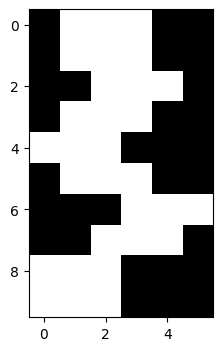

In [15]:
binary = prop_ew.binarize(x_cont_d1_n10)
plt.figure(figsize=(12, 4))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

## Continuous mid-sized

In [16]:
x_cont_mid = RNG.multivariate_normal([0, 0, 0, 0], [[1, 0.5, -0.5, -0.5],[0.5, 1, -0.5, -0.5], [-0.5, -0.5, 1, 0.5], [-0.5, -0.5, 0.5, 1]], size=500)
x_cont_mid


array([[ 0.51804862,  0.32595042,  0.59608585, -1.72305372],
       [ 0.53655875,  1.247018  , -0.77889958, -1.37744004],
       [ 0.31298394, -1.32514726,  0.06413761,  0.22538912],
       ...,
       [ 0.94507148,  0.97792921, -0.62865615, -0.32420563],
       [-0.30191146,  0.86996292, -0.23785889, -1.90637507],
       [ 1.23568598,  1.3918434 , -0.74127089, -1.61094563]],
      shape=(500, 4))

In [17]:
prop = quantile_based_propositionalization(x_cont_mid)
len(prop.v)

120

In [18]:
fat_prop = quantile_based_fat_propositionalization(x_cont_mid)
len(fat_prop.v)

120

In [19]:
prop_ew = equal_width_propositionalization(x_cont_mid)
len(prop_ew.v)

150

In [20]:
%timeit fat_prop.binarize(x_cont_mid)

60.3 μs ± 1.4 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [21]:
%timeit prop.binarize(x_cont_mid)

61.9 μs ± 922 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [22]:
%timeit equal_width_propositionalization(x_cont_mid)

28.5 μs ± 221 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [23]:
%timeit equal_width_propositionalization_numpy(x_cont_mid)

54.9 μs ± 483 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


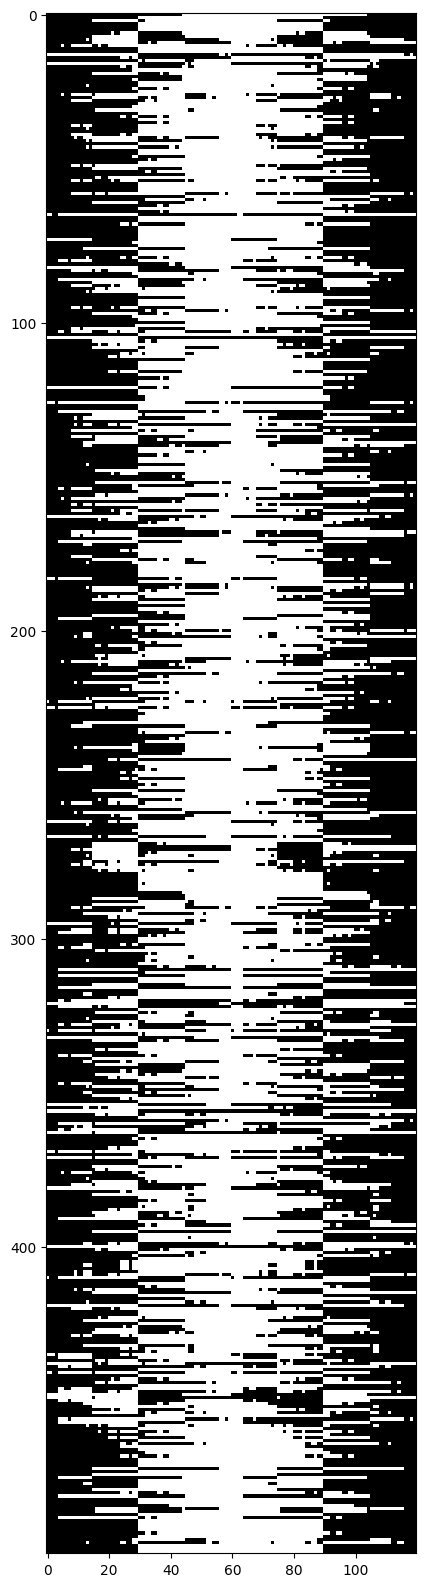

In [24]:
binary = prop.binarize(x_cont_mid)
plt.figure(figsize=(12, 20))
plt.imshow(binary, cmap='Greys', interpolation='none')
plt.show()

In [25]:
x_cont_d100_n1000 = RNG.multivariate_normal(np.zeros(100), np.eye(100), size=1000)
x_cont_d100_n1000.shape

(1000, 100)

In [26]:
%timeit quantile_based_propositionalization(x_cont_d100_n1000)


1.98 ms ± 64.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [27]:
%timeit equal_width_propositionalization(x_cont_d100_n1000)

1.5 ms ± 10.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
%timeit equal_width_propositionalization_numpy(x_cont_d100_n1000)

1.93 ms ± 15.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [29]:
prop_x_cont_d100_n1000 = quantile_based_propositionalization(x_cont_d100_n1000)
fat_prop_x_cont_d100_n1000 = quantile_based_fat_propositionalization(x_cont_d100_n1000)

In [30]:
%timeit prop_x_cont_d100_n1000.binarize(x_cont_d100_n1000)

3.79 ms ± 36.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [31]:
%timeit fat_prop_x_cont_d100_n1000.binarize(x_cont_d100_n1000)

3.78 ms ± 6.72 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## Discrete Data

In [32]:
x_discr_small = RNG.binomial(1, 0.05, 10)
x_discr_small

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [33]:
prop = quantile_based_propositionalization(x_discr_small[:, np.newaxis])
prop.t

array([ 0., -0.])

In [34]:
x_discr_mid = np.random.poisson(6, 1000)[:, np.newaxis]
np.unique(x_discr_mid)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16])

In [35]:
prop = quantile_based_propositionalization(x_discr_mid)
prop.t


array([  2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  -2.,  -3.,
        -4.,  -5.,  -6.,  -7.,  -8.,  -9., -10.])